<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
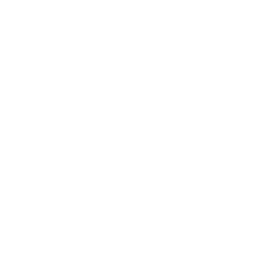
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolace náboru z čtvrtletní na měsíční frekvenci</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacie / Klinické operace &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Manažerské shrnutí

Tento pracovní příklad převádí **čtvrtletní** počty náboru do klinického hodnocení na **měsíční** odhady pomocí PROC EXPAND, aby plánování zdrojů na úrovni pracovišť mohlo běžet v měsíčním rytmu. Syntetické hodnocení zahrnuje **čtyři pracoviště zkoušejících** ve dvou regionech (Severní Amerika a Evropa) po **osm čtvrtletí** (Q1 2024 až Q4 2025), což dává **32 čtvrtletních pozorování**. PROC EXPAND interpoluje řadu každého pracoviště z čtvrtletní na měsíční frekvenci a promění těchto 32 čtvrtletních řádků na **96 měsíčních řádků**. Počty zařazených jsou interpolovány pomocí `METHOD=JOIN` (po částech lineární, což udržuje každý odhad nezáporný) a běžící kumulativní součet je interpolován pomocí `METHOD=SPLINE`. Interpolovaná měsíční řada prochází přesně původními čtvrtletními kotevními body, takže převod přidává vnitročtvrtletní detail, aniž by změnil čtvrtletní hodnoty, které studie již vykázala.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Čtvrtletní počty náboru podle pracoviště (4 pracoviště x 8 čtvrtletí) | 32 |
| WORK.SITE_MASTER | Referenční údaje pracoviště: název, země, region, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Vygenerovat čtvrtletní počty náboru podle pracoviště.
   4 pracoviště x 8 čtvrtletí (Q1 2024 až Q4 2025) = 32 řádků.
   Křivka nájezdu (pomalý start, plató) spolu s mírnou sezónní
   složkou a malým šumem vytváří realistický průběh náboru.
   -------------------------------------------------------- */
data work.enrollment_qtr;
    CALL streaminit(42);
    FORMÁT quarter_date yyq7.;
    DÉLKA region $20;
    POLE capacity[4] _temporary_ (12 9 14 8);
    OPAKUJ site_num = 1 TO 4;
        site_id = cat('SITE-', ZAPSAT(site_num, z3.));
        region  = ifc(site_num <= 2, 'Severní Amerika', 'Evropa');
        base_rate = capacity[site_num];
        OPAKUJ qtr_seq = 0 TO 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            VÝSTUP;
        KONEC;
    KONEC;
    ODSTRANIT site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
SPUSTIT;

/* Průběžný kumulativní nábor v rámci každého pracoviště */
PROCEDURA ŘADIT data=work.enrollment_qtr;
    PODLE site_id quarter_date;
SPUSTIT;

data work.enrollment_qtr;
    NASTAVIT work.enrollment_qtr;
    PODLE site_id;
    UCHOVAT cum_enrolled 0;
    KDYŽ first.site_id PAK cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    ODSTRANIT cum_enrolled;
SPUSTIT;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Hlavní referenční tabulka pracovišť (4 pracoviště, 2 regiony)
   -------------------------------------------------------- */
data work.site_master;
    DÉLKA site_id $8 site_name $40 region $20 country $20 pi_name $30;
    POLE names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    POLE countries[4] $20 _temporary_ ('USA' 'USA' 'Velká Británie' 'Německo');
    OPAKUJ i = 1 TO 4;
        site_id   = cat('SITE-', ZAPSAT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'Severní Amerika', 'Evropa');
        pi_name   = cat('Dr. Vyšetřovatel-', ZAPSAT(i, z2.));
        VÝSTUP;
    KONEC;
    ODSTRANIT i;
SPUSTIT;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Výchozí čtvrtletní souhrn náboru podle regionu
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.enrollment_qtr n sum mean MAX;
    TŘÍDA region;
    PROMĚNNÁ enrolled_count cumulative_enrolled;
    ŠTÍTEK region='Region' enrolled_count='Počet zapsaných' cumulative_enrolled='Kumulativní počet zapsaných';
    VÝSTUP out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
SPUSTIT;

PROCEDURA TISK data=work.qtr_baseline noobs ŠTÍTEK;
    ŠTÍTEK region='Region' total_enrolled='Celkem zapsáno' avg_per_quarter='Průměr za čtvrtletí' max_cumulative='Max. kumulativní počet';
    NÁZEV 'Výchozí čtvrtletní nábor podle regionu';
SPUSTIT;


                                                  The MEANS Procedure

                                  Analysis Variable : enrolled_count Počet zapsaných

        Region                    N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------------
        Evropa                       16    120.0000000      7.5000000     13.0000000
        Severní Amerika              16    115.0000000      7.1875000     10.0000000
        ----------------------------------------------------------------------------

                         Analysis Variable : cumulative_enrolled Kumulativní počet zapsaných

        Region                    N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------------
        Evropa                       16    493.0000000     30.8125000     81.0000000
        Severní Amerika              16    474.0000000     29.625000


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Základ potvrzuje vyvážený návrh: každý region přispívá **16 čtvrtletními pozorováními**. Severní Amerika zapisuje celkem **115 subjektů** (průměr **7,19** na pracoviště-čtvrtletí) a Evropa **120** (průměr **7,50**). Největší kumulativní počet dosažený za osm čtvrtletí je **81** subjektů (evropské SITE-003) oproti **63** v Severní Americe.


---

                                         Výchozí čtvrtletní nábor podle regionu                                         




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


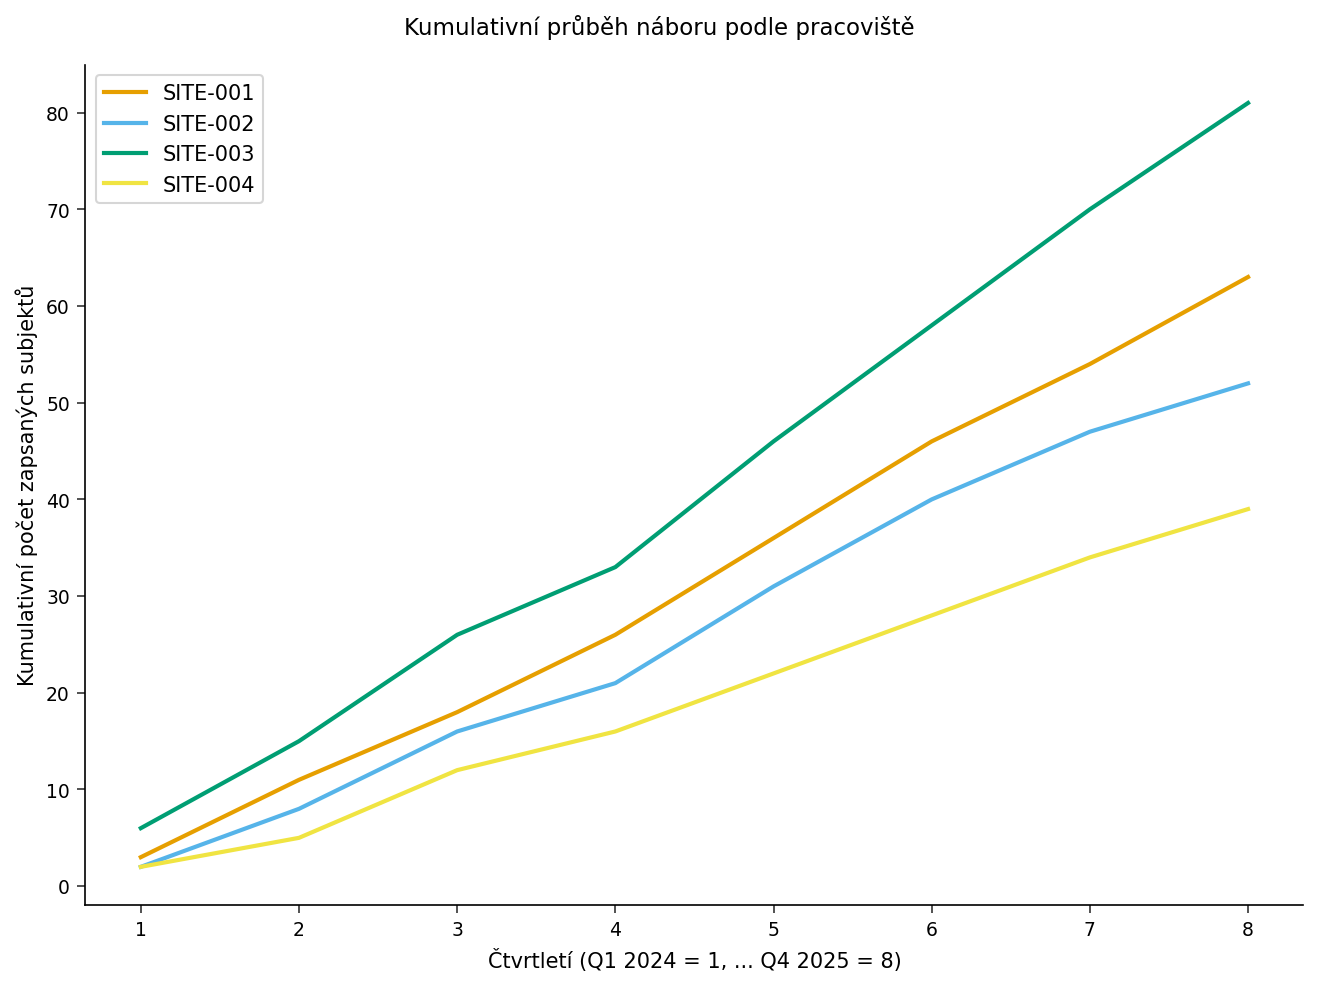

In [4]:
/* --------------------------------------------------------
   Čtvrtletní kumulativní průběh náboru podle pracoviště.
   Vyneseno proti indexu čtvrtletí (1..8) pro přehlednou osu.
   -------------------------------------------------------- */
data work.traj;
    NASTAVIT work.enrollment_qtr;
    PODLE site_id;
    UCHOVAT quarter_index 0;
    KDYŽ first.site_id PAK quarter_index = 0;
    quarter_index + 1;
SPUSTIT;

PROCEDURA SGPLOT data=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ŠTÍTEK='Čtvrtletí (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 TO 8 PODLE 1);
    YAXIS ŠTÍTEK='Kumulativní počet zapsaných subjektů';
    NÁZEV 'Kumulativní průběh náboru podle pracoviště';
SPUSTIT;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND vyžaduje, aby ID proměnná byla seřazená v rámci
   každé BY skupiny, proto před převodem seřadit podle
   pracoviště a čtvrtletí.
   -------------------------------------------------------- */
PROCEDURA ŘADIT data=work.enrollment_qtr;
    PODLE site_id quarter_date;
SPUSTIT;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Převod čtvrtletního náboru na měsíční odhady.

   FROM=QTR / TO=MONTH na příkazu PROC nastaví vstupní a
   výstupní frekvenci; PROC EXPAND interpoluje každou BY
   skupinu (pracoviště) nezávisle podle ID data.

   enrolled_count      -> METHOD=JOIN   (po částech lineární;
                          hodnota toku zůstává nezáporná mezi
                          kotevními body)
   cumulative_enrolled -> METHOD=SPLINE (hladká monotónní křivka)
   -------------------------------------------------------- */
PROCEDURA expand data=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr TO=month;
    PODLE site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=KONEC     METHOD=SPLINE;
SPUSTIT;


                                         Výchozí čtvrtletní nábor podle regionu                                         




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                         Výchozí čtvrtletní nábor podle regionu                                         




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


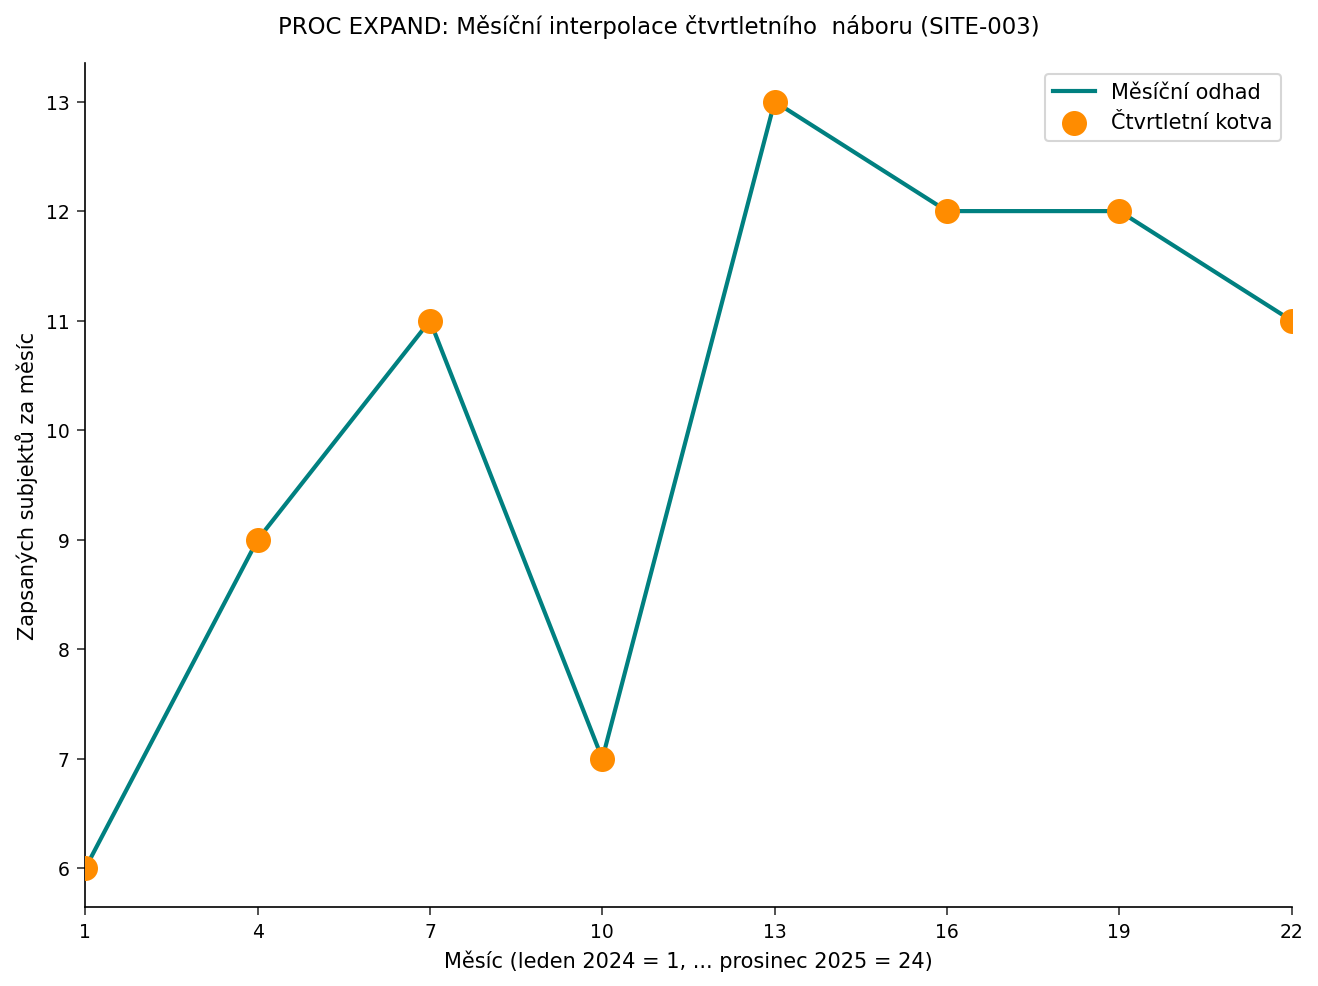

In [7]:
/* --------------------------------------------------------
   ID proměnná nyní nese měsíční data. Přeformátovat ji a
   přidat index měsíce v rámci pracoviště (1..24) pro vykreslení.
   -------------------------------------------------------- */
data work.enrollment_monthly;
    NASTAVIT work.enrollment_monthly;
    PODLE site_id;
    FORMÁT month_date monyy7.;
    month_date = quarter_date;
    UCHOVAT month_index 0;
    KDYŽ first.site_id PAK month_index = 0;
    month_index + 1;
    /* označit měsíce kotevního čtvrtletí (1, 4, 7, ...) */
    KDYŽ mod(month_index - 1, 3) = 0 PAK anchor = enrolled_count;
    JINAK anchor = .;
SPUSTIT;

/* Zobrazit převod pro jedno pracoviště: interpolovaná měsíční
   linie procházející původními čtvrtletními kotevními body. */
PROCEDURA SGPLOT data=work.enrollment_monthly;
    KDE site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Měsíční odhad';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Čtvrtletní kotva';
    XAXIS ŠTÍTEK='Měsíc (leden 2024 = 1, ... prosinec 2025 = 24)'
        integer VALUES=(1 TO 24 PODLE 3);
    YAXIS ŠTÍTEK='Zapsaných subjektů za měsíc';
    NÁZEV 'PROC EXPAND: Měsíční interpolace čtvrtletního '
        'náboru (SITE-003)';
SPUSTIT;


In [8]:
/* --------------------------------------------------------
   Připojit měsíční odhady k metadatům pracoviště a poté
   shrnout měsíční nábor podle regionu.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    VYBRAT e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER PODLE s.region, e.site_id, e.month_date;
QUIT;

PROCEDURA PRŮMĚRY data=work.enrollment_monthly_region n sum mean;
    TŘÍDA region;
    PROMĚNNÁ monthly_estimate cumulative_estimate;
    ŠTÍTEK region='Region' monthly_estimate='Měsíční odhad' cumulative_estimate='Kumulativní odhad';
    VÝSTUP out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
SPUSTIT;

PROCEDURA TISK data=work.region_monthly_summary noobs ŠTÍTEK;
    ŠTÍTEK region='Region' total_monthly_enrolled='Celkem měsíčně zapsáno' avg_monthly_rate='Průměrná měsíční míra';
    NÁZEV 'Měsíční odhady podle regionu';
SPUSTIT;


                                         Výchozí čtvrtletní nábor podle regionu                                         

                                         Výchozí čtvrtletní nábor podle regionu                                         

                                                  The MEANS Procedure

                                 Analysis Variable : monthly_estimate Měsíční odhad

        Region                    N Obs            Sum           Mean
        -------------------------------------------------------------
        Evropa                       44    336.0000000      7.6363636
        Severní Amerika              44    326.0000000      7.4090909
        -------------------------------------------------------------

                               Analysis Variable : cumulative_estimate Kumulativní odhad

        Region                    N Obs            Sum           Mean
        -------------------------------------------------------------
        Evropa     


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretace

PROC EXPAND převedl **32 čtvrtletních záznamů** (4 pracoviště x 8 čtvrtletí) na **96 měsíčních záznamů** pomocí frekvenční konverze podél data každého pracoviště. Interpolovaná měsíční řada prochází původními čtvrtletními kotevními hodnotami přesně, jak ukazuje graf SITE-003: oranžové body jsou osm vykázaných čtvrtletních počtů a modrozelená čára je rozložený měsíční odhad, který je spojuje.

Na měsíční bázi oba regiony sledují blízce. Evropa má v průměru **7,64** zařazených subjektů na pracoviště-měsíc a Severní Amerika **7,41**, s regionálními měsíčními součty **336** a **326** subjektů za interpolovaný horizont. Protože `METHOD=JOIN` neextrapoluje za poslední čtvrtletní kotvu, poslední měsíce dílčího čtvrtletí nenesou žádný odhad a jsou vyloučeny z měsíčních průměrů, což je konzervativní volba pro plánování dopředu.

Tyto měsíční projekce umožňují klinickým operacím přejít z čtvrtletního na měsíční rytmus plánování -- dimenzování zásilek léků, plánování monitorovacích návštěv a reportování náboru Komisi pro sledování bezpečnosti dat (DSMB) -- aniž by přeformulovaly kteroukoli z čtvrtletních hodnot, které studie již uzamkla.


---

In [9]:
/* --------------------------------------------------------
   Export měsíčních projekcí náboru pro navazující plánovací
   nástroje.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
SPUSTIT;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>